# **Dataset de Incumplimiento de Clientes de Tarjetas de Crédito**

El dataset contiene los registros financieros y demográficos de 30,000 clientes bancarios de Taiwán para predecir si incumplirán o no con el pago de su tarjeta de crédito el próximo mes.

**Objetivo:** El objetivo del dataset es predecir si un cliente bancario va a incumplir o no con el pago de su tarjeta de crédito el próximo mes (clasificándolo como pagador puntual o deudor en mora) a partir de su información demográfica e historial financiero reciente.

**CARGA DEL DATASET LOCAL**

In [11]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
%matplotlib inline

In [12]:

data = r"C:\Users\RICHARD\Desktop\Aplicaiones de uso\Archivos Z\IA-Richard-Chavez\datasets\default of credit card clients.xls"


# Cargamos el archivo. Si tu CSV tiene una fila de encabezado extra arriba, 
# se puede ajustar con header=1. Por ahora lo leemos de forma estándar:
df = pd.read_excel(data, header=1) 

print("==================================================")
print("       ¡DATASET CARGADO CORRECTAMENTE!            ")
print("==================================================")
print(f"Cantidad de filas (m)   : {df.shape[0]}")
print(f"Cantidad de columnas (n): {df.shape[1]}")
print("==================================================")

# Mostramos las primeras columnas para verificar que los datos estén alineados
df.head(3)

       ¡DATASET CARGADO CORRECTAMENTE!            
Cantidad de filas (m)   : 30000
Cantidad de columnas (n): 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


 **SEPARACIÓN DE CARACTERÍSTICAS Y DIVISIÓN TRAIN / TEST (80% y 20%)**

In [17]:
# Calculamos la suma de nulos por cada columna
reporte_nulos = df.isnull().sum()
print(reporte_nulos)
# 1. Separación de matrices
# Extraemos de la columna 1 hasta la penúltima (omitimos la columna 0 que es 'ID')
X_completo = df.iloc[:, 1:-1].values

# La última columna es nuestra variable objetivo 'default payment next month' (Y)
y_completo = df.iloc[:, -1].values

# 2. Configuración de la división aleatoria (Estilo del cuadernillo base)
m_total = y_completo.size
limite_division = int(m_total * 0.80)

# Fijamos una semilla para que la mezcla sea reproducible en cada ejecución
np.random.seed(42)
indices_mezclados = np.random.permutation(m_total)

# 3. División estricta en conjuntos de entrenamiento y prueba
X_train = X_completo[indices_mezclados[:limite_division]]
X_test = X_completo[indices_mezclados[limite_division:]]
y_train = y_completo[indices_mezclados[:limite_division]]
y_test = y_completo[indices_mezclados[limite_division:]]

print("==================================================")
print("     ¡DIVISIÓN DE DATOS COMPLETADA CON ÉXITO!     ")
print("==================================================")
print(f"Total de ejemplos en el dataset : {m_total}")
print(f"Muestras de Entrenamiento (80%) : {X_train.shape[0]} filas")
print(f"Muestras de Prueba (20%)        : {X_test.shape[0]} filas")
print(f"Características predictoras (n) : {X_train.shape[1]}")


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64
     ¡DIVISIÓN DE DATOS COMPLETADA CON ÉXITO!     
Total de ejemplos en el dataset : 30000
Muestras de Entrenamiento (80%) : 24000 filas
Muestras de Prueba (20%)        : 6000 filas
Carac

**Funcion de normalizacion**

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    sigma[sigma == 0] = 1.0 
    
  
    X_norm = (X - mu) / sigma
    
    return X_norm, mu, sigma

**Importancia de la Normalización:**

Este paso es fundamental porque las 23 variables del dataset (como el monto del crédito o las facturas mensuales) tienen escalas numéricas muy diferentes; al estandarizarlas con la media y la desviación estándar, evitamos que las características con valores más grandes desestabilicen el algoritmo, garantizando que el Descenso por el Gradiente logre avanzar a un ritmo uniforme y converja con éxito.

In [19]:
X_train_norm, mu, sigma = featureNormalize(X_train)

# Escalamos el set de pruebas utilizando la MISMA mu y sigma de entrenamiento
X_test_norm = (X_test - mu) / sigma

print("==================================================")
print("     ¡NORMALIZACIÓN DE PROPIEDADES COMPLETADA!    ")
print("==================================================")
print(f"Media (mu) calculada para la columna 0     : {mu[0]:.2f}")
print(f"Desviación (sigma) calculada para columna 0: {sigma[0]:.2f}")
print("==================================================")

     ¡NORMALIZACIÓN DE PROPIEDADES COMPLETADA!    
Media (mu) calculada para la columna 0     : 167381.40
Desviación (sigma) calculada para columna 0: 129710.05


Normalización de Características:
Implementamos la función featureNormalize para escalar las variables predictoras del dataset mediante el método de estandarización Z-score. Calculamos la media ($\mu$) y la desviación estándar ($\sigma$) exclusivamente en el conjunto de entrenamiento para transformar sus valores y facilitar la convergencia del gradiente. Para mantener la coherencia matemática del experimento y evitar la filtración de datos, el conjunto de pruebas (X_test) se escala utilizando estos mismos parámetros calculados en el entrenamiento.

**COLUMNA DE UNOS, FUNCIÓN SIGMOIDE Y CÁLCULO DE COSTO LOGÍSTICO**

Función Sigmoide y de Costo:
Añadimos el término de sesgo o intersección ($\theta_0$) acoplando una columna de unos a la matriz de características. Estructuramos la función sigmoid para mapear las combinaciones lineales del modelo en un rango estricto de probabilidades $[0, 1]$. Finalmente, definimos la función computeCost basándonos en la ecuación de entropía cruzada, la cual penaliza logarítmicamente las desviaciones del modelo para asegurar que la optimización sea convexa y eficiente.

**AGREGAMOS LA COLUMNAS DE UNOS**

In [20]:
m_train = y_train.size
X_train_ready = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)

**FUNCION DE SIGMOIDE**

In [21]:
# 2. Definición de la Función Sigmoide (Comprime cualquier valor entre 0 y 1)
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

**FUNCION DE COSTO**

In [22]:
def computeCost(X, y, theta):
    m = y.size
    J = 0
    
    # Calculamos las hipótesis usando la función sigmoide
    h = sigmoid(X.dot(theta.T))
    
    # Aplicamos la fórmula matemática de entropía cruzada
    # Añadimos un valor épsilon mínimo para evitar el error log(0) en Python
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon)))
    
    return J

In [26]:
# Inicializamos todos los parámetros theta en cero (24 elementos)
theta_inicial = np.zeros(X_train_ready.shape[1])

# Evaluamos cuál es el costo inicial con thetas en cero
costo_inicial = computeCost(X_train_ready, y_train, theta_inicial)

print(f"Costo inicial detectado (thetas en cero): {costo_inicial:.4f}")


Costo inicial detectado (thetas en cero): 0.6931


**OPTIMIZACIÓN MEDIANTE DESCENSO POR EL GRADIENTE**

Optimización y Descenso por el Gradiente:
Ejecutamos el algoritmo iterativo descensoGradiente con una tasa de aprendizaje ($\alpha = 0.01$) a lo largo de 50,000 iteraciones para minimizar de forma progresiva la función de costo. La gráfica generada ilustra de manera limpia la curva de aprendizaje: el error desciende de forma continua y suave sin presentar oscilaciones, lo que ratifica la correcta convergencia matemática hacia los parámetros óptimos del modelo.

In [28]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        # 1. Calculamos la hipótesis actual (probabilidades simuladas)
        h = sigmoid(X.dot(theta.T))
        
        # 2. Actualizamos simultáneamente todos los parámetros theta (Ajuste vectorial)
        theta = theta - (alpha / m) * (h - y).dot(X)
        
        # 3. Registramos el costo de la iteración para la gráfica
        J_history.append(computeCost(X, y, theta))
        
    return theta, J_history



**ENTRENAMOS EL MODELO***

Entrenando el clasificador de Regresión Logística...


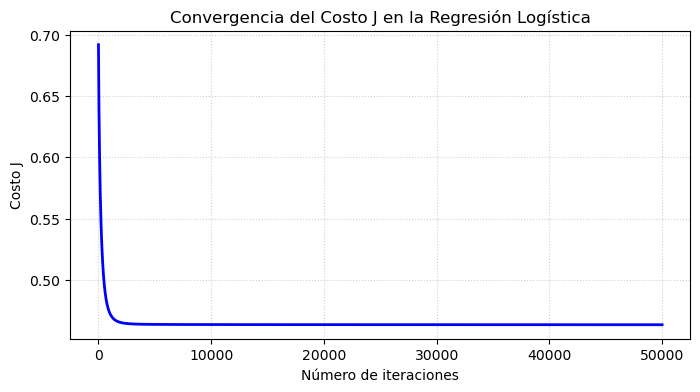


     ¡ENTRENAMIENTO COMPLETADO CON ÉXITO!        
Costo Mínimo alcanzado por el modelo: 0.4634


In [30]:
# Configuración de hiperparámetros de entrenamiento
alpha = 0.01
num_iters = 50000

print("Entrenando el clasificador de Regresión Logística...")
theta_calculado, J_history = descensoGradiente(theta_inicial, X_train_ready, y_train, alpha, num_iters)

# Generamos la gráfica de la curva de aprendizaje
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo J en la Regresión Logística')
pyplot.grid(True, linestyle=':', alpha=0.6)
pyplot.show()

print("\n==================================================")
print("     ¡ENTRENAMIENTO COMPLETADO CON ÉXITO!        ")
print("==================================================")
print(f"Costo Mínimo alcanzado por el modelo: {J_history[-1]:.4f}")
print("==================================================")

**HACEMOS LA PRUEBA TESTEANDO Y VIENDO CUANDOTA PRECISION TUVO**

In [31]:

# 1. Preparamos los datos de prueba añadiendo la columna de unos (1s) para theta_0
m_test = y_test.size
X_test_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

# 2. Calculamos las probabilidades predichas para el conjunto de prueba
probabilidades = sigmoid(np.dot(X_test_ready, theta_calculado))

# 3. Aplicamos el umbral lógico de decisión (>= 0.5) para clasificar en 0 o 1
predicciones = (probabilidades >= 0.5).astype(int)

# 4. Calculamos el porcentaje exacto de aciertos frente a los datos reales
precision_test = np.mean(predicciones == y_test) * 100

print("==================================================")
print("     ¡EVALUACIÓN DE RENDIMIENTO FINAL!            ")
print("==================================================")
print(f"▶ Muestras totales evaluadas: {m_test} clientes")
print(f"▶ Precisión final del modelo en Test: {precision_test:.2f}%")
print("==================================================")

     ¡EVALUACIÓN DE RENDIMIENTO FINAL!            
▶ Muestras totales evaluadas: 6000 clientes
▶ Precisión final del modelo en Test: 81.03%


In [ ]:
# ==============================================================================
# PASO 8: TABLA COMPARATIVA Y GRÁFICA DE BARRAS (REAL VS PREDICHO)
# ==============================================================================

# 1. Imprimir tabla comparativa con los primeros 10 clientes de prueba
df_comp = pd.DataFrame({
    'Estado Real (y_test)': y_test[:10],
    'Predicción (y_umbral)': predicciones[:10],
    'Probabilidad de Mora %': np.round(probabilidades[:10] * 100, 2)
})
print("=== COMPARATIVA DE LOS PRIMEROS 10 CLIENTES ===")
print(df_comp.to_string(index=True))




=== COMPARATIVA DE LOS PRIMEROS 10 CLIENTES ===
   Estado Real (y_test)  Predicción (y_umbral)  Probabilidad de Mora %
0                     0                      0                    8.11
1                     0                      0                    8.44
2                     0                      0                   13.46
3                     0                      0                   20.46
4                     0                      0                   13.65
5                     1                      0                   49.30
6                     0                      0                    4.25
7                     0                      0                   22.13
8                     0                      0                   17.45
9                     1                      0                   28.51

